## Super-resolution Tool --> SVD-SR

*Code updated for TENSORFLOW 2.15+ (Feb 2026)*

Details of the implementation in:

[**Barragán, G., Hetherington, A., Abadía-Heredia, R., Garicano-Mena, J., Le Clainche, S.**, *HOSVD-SR: A Physics-Based Deep Learning Framework for Super-Resolution in Fluid Dynamics, arXiv:2504.17994, 2025*._](https://arxiv.org/abs/2504.17994)


In [33]:

import numpy as np
import time
import scipy.io
import matplotlib.pyplot as plt
import os
import tensorflow as tf
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.layers import Dense, Reshape, Flatten
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input

print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {tf.keras.__version__}")

TensorFlow: 2.20.0
Keras: 3.13.2


In [34]:
try:
  import mat73
except:
  !pip install -q mat73
  import mat73

### Mounting Google Drive and Dir configuration

In [35]:
from google.colab import drive
drive.mount('/content/drive')

# set working directory
os.chdir("/content/drive/My Drive/Colab_Notebooks/00_Master_AI_2026/Databases")

# Check current working directory
retval = os.getcwd()
print("Current working directory %s" % retval)

!ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Current working directory /content/drive/My Drive/Colab_Notebooks/00_Master_AI_2026/Databases
astronaut.jpg		       NN_Models
best_model.h5		       saved_models
Cylinder_2D_Re100	       saved_models_POD-DL
Cylinder_3D_Re280	       SVD-DLinear.pth
Cylinder_turbulent_VKI_Re4000  Test_case
Diffusion_Models	       ToyModel_Lorenz
Laminar_Flame		       Video_Record
loss_evolution_hybrid_dl.jpg


### Load database

In [36]:
# Set database
# Turbulence = 0  # Load cylinder at Re=100
# Turbulence = 1  # Load cylinder at Re=4000

Turbulence = 0

if Turbulence == 0:
    # Load numerical database, Re=100
    data_dict = mat73.loadmat('Cylinder_2D_Re100/Tensor.mat')
    start_snap = 1
    numericalTensor = data_dict['Tensor'][:,:,:,start_snap-1:]
else:
    # Load experimental database in turbulent regime
    data_dict = mat73.loadmat('Cylinder_turbulent_VKI_Re4000/Tensor_Re4000.mat')
    start_snap = 1
    numericalTensor = data_dict['Tensor'][:,:,:,start_snap-1:]

us_tensor = np.transpose(numericalTensor, axes=(3,1,2,0))

# Print the size of the Tensor
print("Size of the Tensor:", us_tensor.shape)

Size of the Tensor: (151, 199, 449, 2)


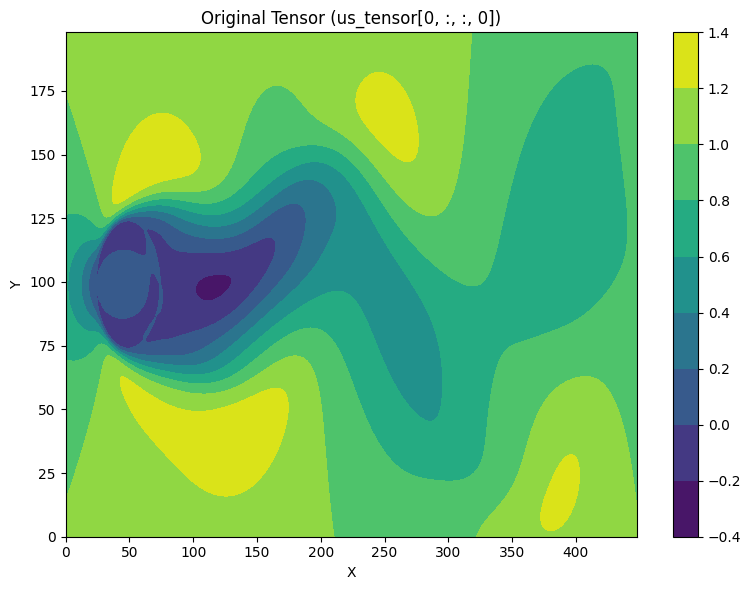

In [37]:
# Plot original database
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
c = ax.contourf(us_tensor[0, :, :, 0])
fig.colorbar(c, ax=ax, orientation='vertical')
ax.set_title('Original Tensor (us_tensor[0, :, :, 0])')
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.tight_layout()
plt.show()

### Downscaling and pre-processing

Shape of the downscaled tensor (n_time, n_y, n_x, n_var): (151, 5, 12, 2)


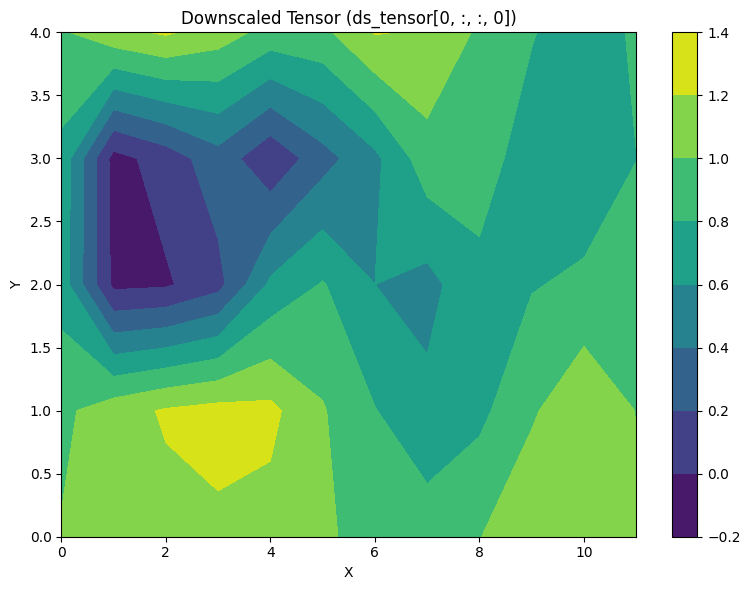

In [38]:
# downscale or import the downscaled tensor
downscaling_factor = 40
ds_tensor = us_tensor[:,::downscaling_factor, ::downscaling_factor, :]

print(f'Shape of the downscaled tensor (n_time, n_y, n_x, n_var): {ds_tensor.shape}')
Xr = ds_tensor.copy()

# Plot downsampled database
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
c = ax.contourf(ds_tensor[0, :, :, 0])
fig.colorbar(c, ax=ax, orientation='vertical')
ax.set_title('Downscaled Tensor (ds_tensor[0, :, :, 0])')
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.tight_layout()
plt.show()

In [39]:
nt, ny, nx, nvar = ds_tensor.shape  # extract the points on each dimension
print(f"nt={nt}, ny={ny}, nx={nx}, nvar={nvar}")

# Apply scaling
apply_scaling = 'yes'
if apply_scaling:
    var_min = np.min(Xr, axis=(0, 1, 2))
    var_max = np.max(Xr, axis=(0, 1, 2))
    Xr = (Xr - var_min) / (var_max - var_min)

nt=151, ny=5, nx=12, nvar=2


### Calculate SVD for each snapshot

In [40]:
XUds = np.zeros([nt, ny, ny, nvar])
XSds = np.zeros([nt, ny, ny, nvar])
XVds = np.zeros([nt, ny, nx, nvar])

for i in range(nt):
    for j in range(nvar):
        U, S, V = np.linalg.svd(Xr[i, ..., j], full_matrices=False)
        XUds[i, ..., j], XSds[i, ..., j], XVds[i, ..., j] = U, np.diag(S), V

print(f"XUds shape: {XUds.shape}")
print(f"XSds shape: {XSds.shape}")
print(f"XVds shape: {XVds.shape}")

XUds shape: (151, 5, 5, 2)
XSds shape: (151, 5, 5, 2)
XVds shape: (151, 5, 12, 2)


### Split train/test

In [41]:
train_ratio = 0.8
n_train = int(nt * train_ratio)
train_ind, test_ind = np.arange(nt)[:n_train], np.arange(nt)[n_train:]

Xr_train, Xr_test = us_tensor[train_ind], us_tensor[test_ind]
XUds_train, XUds_test = XUds[train_ind], XUds[test_ind]
XSds_train, XSds_test = XSds[train_ind], XSds[test_ind]
XVds_train, XVds_test = XVds[train_ind], XVds[test_ind]

in_U_dim = XUds.shape[1:]
in_S_dim = XSds.shape[1:]
in_V_dim = XVds.shape[1:]
out_dim = Xr_train.shape[1:]

print(f"in_U_dim: {in_U_dim}")
print(f"in_S_dim: {in_S_dim}")
print(f"in_V_dim: {in_V_dim}")
print(f"out_dim: {out_dim}")

in_U_dim: (5, 5, 2)
in_S_dim: (5, 5, 2)
in_V_dim: (5, 12, 2)
out_dim: (199, 449, 2)


### Build and compile model

In [42]:
from tensorflow.keras.layers import Lambda

neurons, act_func, act_fun1, learn_rate = 10, 'relu', 'linear', 1e-3

def create_model(in_U_dim, in_S_dim, in_V_dim, out_dim):
    in_U, in_S, in_V = Input(in_U_dim), Input(in_S_dim), Input(in_V_dim)

    # Takes the flattened input and passes it through a dense (fully connected) layer
    u = Dense(neurons, activation=act_func)(Flatten()(in_U))
    # The number of neurons in this layer is calculated as the product: out_dim[0] * in_U_dim[1] * in_U_dim[2]
    # Calculates u with dimension neurons= Nx x NumberModes x NumberComponents --> then reshape
    XUus = Reshape((out_dim[0], in_U_dim[1], in_U_dim[2]))(
        Dense(out_dim[0] * in_U_dim[1] * in_U_dim[2], activation=act_fun1)(u)
    )

    # Takes the flattened input and passes it through a dense (fully connected) layer
    v = Dense(neurons, activation=act_func)(Flatten()(in_V))
    # The number of neurons in this layer is calculated as the product: in_V_dim[0] * out_dim[1] * in_V_dim[2]
    # Calculates u with dimension neurons= NumberModes x Ny x NumberComponents --> then reshape
    XVus = Reshape((in_V_dim[0], out_dim[1], in_V_dim[2]))(
        Dense(in_V_dim[0] * out_dim[1] * in_V_dim[2], activation=act_fun1)(v)
    )

    # Envolver tf.einsum
    # Multiply element by element in the tensor
    X_hat = Lambda(
        lambda x: tf.einsum('ijkl,iknl,inpl->ijpl', x[0], x[1], x[2])
    )([XUus, in_S, XVus])

    model = Model(inputs=[in_U, in_S, in_V], outputs=X_hat)
    model.compile(loss='mse', optimizer=Adam(learn_rate), metrics=['mse'])

    return model

model = create_model(in_U_dim, in_S_dim, in_V_dim, out_dim)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 5, 5, 2)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_8       │ (None, 5, 12, 2)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 50)        │          0 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 120)       │          0 │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 10)        │        510 │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 10)        │      1,210 │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1990)      │     21,890 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 4490)      │     49,390 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 199, 5, 2) │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 5, 5, 2)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_5 (Reshape) │ (None, 5, 449, 2) │          0 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 199, 449,  │          0 │ reshape_4[0][0],  │
│                     │ 2)                │            │ input_layer_7[0]… │
│                     │                   │            │ reshape_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 73,000 (285.16 KB)

 Trainable params: 73,000 (285.16 KB)

 Non-trainable params: 0 (0.00 B)

### Training

In [43]:
# ====== Training ======
callbacks = [
    ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True),
    EarlyStopping(monitor='val_loss', patience=25)
]

history = model.fit(
    [XUds_train, XSds_train, XVds_train],
    Xr_train,
    batch_size=16,
    epochs=300,  # optimum value - 300 epochs
    validation_split=0.15,
    shuffle=True,
    callbacks=callbacks
)

Epoch 1/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - loss: 0.4378 - mse: 0.4378

7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 550ms/step - loss: 0.4375 - mse: 0.4375 - val_loss: 0.4351 - val_mse: 0.4351
Epoch 2/300
1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.4353 - mse: 0.4353

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.4307 - mse: 0.4307 - val_loss: 0.4187 - val_mse: 0.4187
Epoch 3/300
1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.4173 - mse: 0.4173

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.4043 - mse: 0.4043 - val_loss: 0.3710 - val_mse: 0.3710
Epoch 4/300
1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.3694 - mse: 0.3694

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.3337 - mse: 0.3337 - val_loss: 0.2691 - val_mse: 0.2691
Epoch 5/300
1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.2546 - mse: 0.2546

...

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0014 - mse: 0.0014 - val_loss: 0.0014 - val_mse: 0.0014
Epoch 291/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0014 - mse: 0.0014 - val_loss: 0.0014 - val_mse: 0.0014
Epoch 292/300
6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0014 - mse: 0.0014

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0014 - mse: 0.0014 - val_loss: 0.0014 - val_mse: 0.0014
Epoch 293/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0014 - mse: 0.0014 - val_loss: 0.0014 - val_mse: 0.0014
Epoch 294/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0014 - mse: 0.0014 - val_loss: 0.0014 - val_mse: 0.0014
Epoch 295/300
1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0014 - mse: 0.0014

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0014 - mse: 0.0014 - val_loss: 0.0014 - val_mse: 0.0014
Epoch 296/300
1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.0014 - mse: 0.0014

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0014 - mse: 0.0014 - val_loss: 0.0014 - val_mse: 0.0014
Epoch 297/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0014 - mse: 0.0014 - val_loss: 0.0014 - val_mse: 0.0014
Epoch 298/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0014 - mse: 0.0014 - val_loss: 0.0014 - val_mse: 0.0014
Epoch 299/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0014 - mse: 0.0014 - val_loss: 0.0014 - val_mse: 0.0014
Epoch 300/300
1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0014 - mse: 0.0014

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0014 - mse: 0.0014 - val_loss: 0.0014 - val_mse: 0.0014


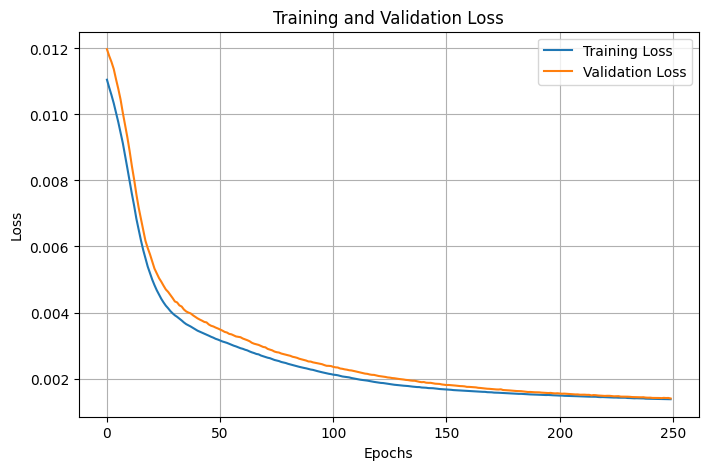

In [44]:
# Plot training & validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'][50:], label='Training Loss')
plt.plot(history.history['val_loss'][50:], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.grid()
plt.show()

### Prediction and evaluation

In [45]:
Rec = model.predict([XUds_test, XSds_test, XVds_test])
print(f"Reconstruction shape: {Rec.shape}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step
Reconstruction shape: (31, 199, 449, 2)


### Visualization of results

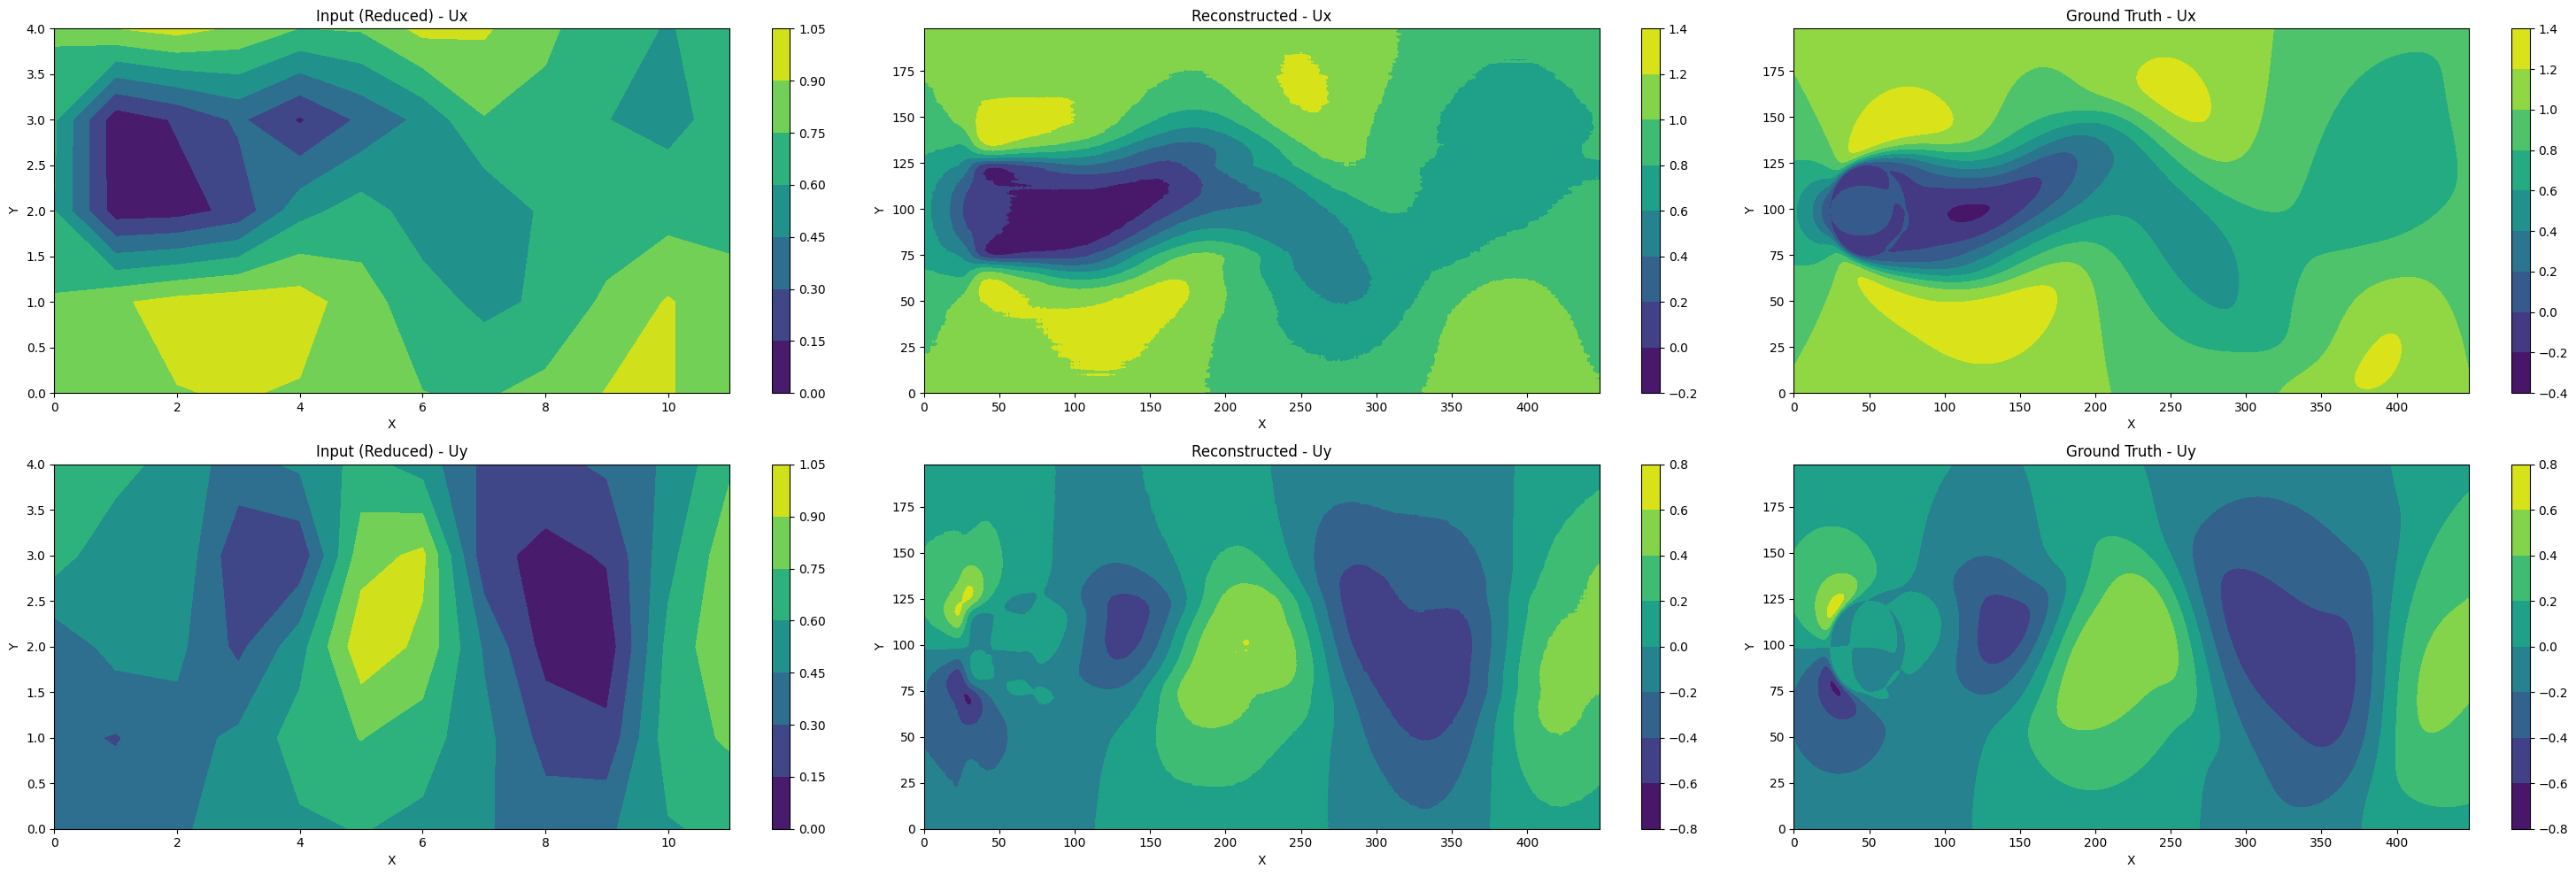

In [46]:
# PLOT RESULTS
fig, axes = plt.subplots(2, 3, figsize=(30, 10))

# --- COLUMN 1: Input (Reduced dimension) ---
c1 = axes[0, 0].contourf(Xr[0, :, :, 0])
fig.colorbar(c1, ax=axes[0, 0])
axes[0, 0].set_title('Input (Reduced) - Ux')

c1b = axes[1, 0].contourf(Xr[0, :, :, 1])
fig.colorbar(c1b, ax=axes[1, 0])
axes[1, 0].set_title('Input (Reduced) - Uy')


# --- COLUMN 2: Reconstructed ---
c2 = axes[0, 1].contourf(Rec[0, :, :, 0])
fig.colorbar(c2, ax=axes[0, 1])
axes[0, 1].set_title('Reconstructed - Ux')

c2b = axes[1, 1].contourf(Rec[0, :, :, 1])
fig.colorbar(c2b, ax=axes[1, 1])
axes[1, 1].set_title('Reconstructed - Uy')


# --- COLUMN 3: Original ---
c3 = axes[0, 2].contourf(us_tensor[0, :, :, 0])
fig.colorbar(c3, ax=axes[0, 2])
axes[0, 2].set_title('Ground Truth - Ux')

c3b = axes[1, 2].contourf(us_tensor[0, :, :, 1])
fig.colorbar(c3b, ax=axes[1, 2])
axes[1, 2].set_title('Ground Truth - Uy')

# Formatting
for ax in axes.flat:
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

plt.tight_layout()
plt.show()